# **Business Case 1: Segmenting Clients**

In this executable notebook you have a logical track of the work, with working code snippets, some method suggestions (absolutely non-binding). Basically: examples of what you can do.


Remember: when it comes to data modeling, there is almost never a "one size fits all", thus you can take various ways to solve the problem.


So feel free to take this code as a draft, change it, even significantly, following your modeling vision. Feel free to explore data and methods and gain experience (yes, even getting it wrong and getting results you don't like - it's quite normal in real applications). You will find some **"HINTS"**: they are just suggestions for you - I mean, you don't have to follow all the suggestions, and if you want you can follow your inspiration, my "Hints" are just ideas...

Remember: **experimenting with data - that's the purpose of this Machine Learning Lab.**

<br>

## Goal

Here we have a random extraction of **a (real-world) dataset made up of a bank's customers**. The data is **anonymous, mostly clean and normalized in [0, 1]**.

We intend to **segment these customers using Data Science techniques** (essentially Unsupervised Machine Learning); this is a segmentation carried out from the perspective of the financial services sector.


The **dataset is called "Dataset1_BankClients"** and is saved as a .xls file.

<br>

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import gower
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)

In [4]:
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop

# Let's inspect the first 5 record
data.head()



,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data
We extract the variables of interest, also dividing into:
* **Numerical**.
* **Categorical** (excluding the ID, which is not informative at this level).


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

## Outlier Analysis

In [5]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


In [6]:
# ==========================================
# OBJECTIVE 2: FAMD PIPELINE (Insurance & Protection)
# ==========================================

# 1. Define the "Risk Engine"
active_risk_cols = ['Debt', 'FamilySize', 'Income', 'Wealth','Saving', 'Job']
df_active_mixed = data[active_risk_cols].copy()

# Ensure categorical variables are typed correctly for Prince
df_active_mixed['Job'] = df_active_mixed['Job'].astype(str)

print("Original Mixed Dataset:")
display(df_active_mixed.head(3))

# 2. Initialize and Fit FAMD
# We reduce the 6 mixed variables down to 5 purely continuous latent dimensions
famd = prince.FAMD(
    n_components=3,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

# 3. Check the Variance Explained
# This proves to the professor that your dimensions captured the actual data!
# 3. Check the Variance Explained (Updated for Prince v0.13+)
try:
    # Newer versions use this attribute
    explained_variance = famd.percentage_of_variance_
except AttributeError:
    # Fallback just in case
    explained_variance = famd.explained_inertia_

# The newer library outputs actual percentages (e.g., 45.2 instead of 0.452)
# We do a quick check to see if we need to multiply by 100
total_var = sum(explained_variance)
if total_var <= 1.0:
    total_var *= 100
    explained_variance = [v * 100 for v in explained_variance]

print(f"\nTotal Variance Explained by 3 Dimensions: {total_var:.2f}%")

Original Mixed Dataset:


,Debt,FamilySize,Income,Wealth,Saving,Job
0,0.262070,4,0.668046,0.702786,0.283222,1
1,0.730430,1,0.858453,0.915043,0.821590,2
2,0.441272,2,0.926818,0.898316,0.503790,2



FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3
0,0.792715,-0.402484,-3.278802
1,-2.844434,0.968821,-0.238385
2,-1.546880,0.133476,-0.069558



Total Variance Explained by 3 Dimensions: 37.19%


Silhouette Score for k=4: 0.299


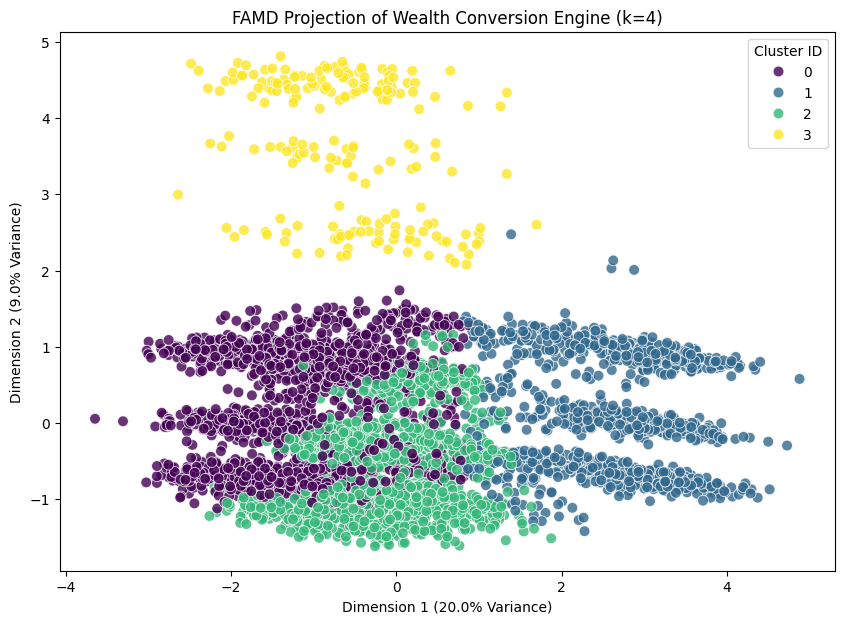


--- CLUSTER PROFILES (The Business Truth) ---


,Wealth,Income,Debt,Saving,FamilySize,Job
Cluster_ID,,,,,,
0,0.73,0.73,0.54,0.60,1,2
1,0.38,0.38,0.14,0.30,1,5
2,0.53,0.51,0.47,0.55,2,2
3,0.59,0.63,0.49,0.61,1,3


In [7]:
# 4. Standard Euclidean Clustering on the FAMD dimensions
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_famd)

sil_score = silhouette_score(X_famd, cluster_labels)
print(f"Silhouette Score for k={optimal_k}: {sil_score:.3f}")

# 5. Plot the Manifold (Updated labels)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_famd['Dim_1'], 
    y=X_famd['Dim_2'], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60, alpha=0.8
)

plt.title(f'FAMD Projection of Wealth Conversion Engine (k={optimal_k})')
plt.xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)')
plt.ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)')
plt.legend(title='Cluster ID')
plt.show()

# 6. Profile the Clusters to find the Business Target
df_active_mixed['Cluster_ID'] = cluster_labels
print("\n--- CLUSTER PROFILES (The Business Truth) ---")
display(df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'FamilySize': lambda x: x.mode()[0],
    'Job': lambda x: x.mode()[0]
}).round(2))

In [8]:
# 1. Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# 2. Extract column correlations (for continuous variables)
# This tells you the direction (positive/negative correlation)
try:
    correlations = famd.column_correlations(df_active_mixed)
    print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS ---")
    display(correlations.round(3))
except AttributeError:
    pass # Older versions of Prince might handle this differently

--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2
variable,,,
Debt,22.93%,0.73%,1.13%
Income,17.70%,2.13%,4.93%
Wealth,17.65%,0.59%,4.66%
Saving,19.84%,0.16%,2.12%
FamilySize,0.46%,52.99%,41.66%
Job,21.43%,43.40%,45.50%


NotImplementedError: FAMD inherits from PCA, but this method is not implemented yet

In [9]:
# df_active_original should be your raw Wealth, Income, Debt, Saving, Investments data
df_active_mixed['Cluster_ID'] = cluster_labels

print("--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'FamilySize': lambda x: x.mode()[0],
    'Job': lambda x: x.mode()[0]
}).round(1)

display(profile_active)

--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,FamilySize,Job
Cluster_ID,,,,,,
0,0.7,0.7,0.5,0.6,1,2
1,0.4,0.4,0.1,0.3,1,5
2,0.5,0.5,0.5,0.6,2,2
3,0.6,0.6,0.5,0.6,1,3


In [14]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 55.8
Most common Gender: 0
Digital Propensity: 0.63
BankFriend Propensity: 0.67
Financial Education: 0.61
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    51.5%
1    48.5%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    76.0%
2    14.5%
3     9.5%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    40.3%
2    36.3%
1    23.4%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  55.765859  0.629858    0.672419  0.611303
min   19.000000  0.011487    0.158130  0.047841
50%   55.000000  0.668642    0.697028  0.638129
max   95.000000  0.962253    0.974230  0.962526
--- VOLUME SUMMARY FOR CLUSTER 0 ---
Total People in Cluster: 1939
Percentage of Total Base: 38.8%
----------------------------------------


In [16]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 75.1
Most common Gender: 1
Digital Propensity: 0.35
BankFriend Propensity: 0.62
Financial Education: 0.35
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    56.4%
0    43.6%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    65.9%
2    24.9%
3     9.2%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    47.3%
1    42.2%
3    10.6%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  75.082364  0.354183    0.620027  0.351200
min   19.000000  0.000000    0.137763  0.000000
50%   80.000000  0.330810    0.635099  0.341715
max   95.000000  0.971778    0.965270  0.914614
--- VOLUME SUMMARY FOR CLUSTER 1 ---
Total People in Cluster: 1032
Percentage of Total Base: 20.7%
----------------------------------------


In [17]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 58.7
Most common Gender: 1
Digital Propensity: 0.50
BankFriend Propensity: 0.57
Financial Education: 0.49
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    52.8%
0    47.2%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    71.3%
2    14.4%
3    14.3%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    44.0%
1    40.7%
3    15.3%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  58.658643  0.504019    0.568421  0.489626
min   19.000000  0.000000    0.155014  0.078713
50%   58.000000  0.503308    0.572925  0.492347
max   95.000000  0.953432    0.972129  0.913906
--- VOLUME SUMMARY FOR CLUSTER 2 ---
Total People in Cluster: 1828
Percentage of Total Base: 36.6%
----------------------------------------


In [19]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_risk_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 3
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Area', 'CitySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 3 ---
Average Age: 46.9
Most common Gender: 1
Digital Propensity: 0.65
BankFriend Propensity: 0.56
Financial Education: 0.56
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 3 ---

--- Gender Distribution ---
Gender
1    77.3%
0    22.7%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    83.0%
2    11.3%
3     5.7%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    58.2%
2    32.0%
1     9.8%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  46.917526  0.646492    0.564558  0.564954
min   19.000000  0.004711    0.190427  0.185410
50%   43.000000  0.685815    0.562444  0.566882
max   95.000000  0.969335    0.903417  0.934461
--- VOLUME SUMMARY FOR CLUSTER 3 ---
Total People in Cluster: 194
Percentage of Total Base: 3.9%
----------------------------------------
